In [ ]:
import pandas as pd
import numpy as np

# -----------------------------
# 1. File paths
# -----------------------------
world_bank_path = "/content/World Bank 2023.csv"
pollution_path = "/content/global air pollution dataset 2023.csv"

# -----------------------------
# 2. Load datasets
# -----------------------------
wb_raw = pd.read_csv(world_bank_path)
pollution = pd.read_csv(pollution_path)

# -----------------------------
# 3. Clean World Bank data
# -----------------------------
wb_raw = wb_raw.dropna(subset=["Country Name", "Country Code", "Series Code"])

wb_raw["2023 [YR2023]"] = pd.to_numeric(
    wb_raw["2023 [YR2023]"].replace("..", np.nan),
    errors="coerce"
)

indicator_names = {
    "SP.POP.TOTL": "population_total",
    "NY.GDP.PCAP.CD": "gdp_per_capita",
    "SP.URB.TOTL.IN.ZS": "urban_population_pct",
    "EG.FEC.RNEW.ZS": "renewable_energy_pct",
    "EG.USE.PCAP.KG.OE": "energy_use_per_capita",
    "EN.POP.DNST": "population_density",
    "EN.GHG.ALL.PC.CE.AR5": "ghg_emissions_per_capita",
    "NV.IND.TOTL.ZS": "industry_value_added_pct"
}

wb_raw["variable"] = wb_raw["Series Code"].map(indicator_names)

wb = (
    wb_raw.dropna(subset=["variable"])
    .pivot_table(
        index=["Country Name", "Country Code"],
        columns="variable",
        values="2023 [YR2023]",
        aggfunc="first"
    )
    .reset_index()
)

wb.columns.name = None

# -----------------------------
# 4. Clean country names
# -----------------------------
def clean_country_name(name):
    if pd.isna(name):
        return np.nan

    name = str(name).strip().lower()

    replacements = {
        "united states of america": "united states",
        "usa": "united states",
        "russia": "russian federation",
        "south korea": "korea, rep.",
        "north korea": "korea, dem. people's rep.",
        "iran": "iran, islamic rep.",
        "venezuela": "venezuela, rb",
        "egypt": "egypt, arab rep.",
        "slovakia": "slovak republic",
        "czechia": "czech republic",
        "turkey": "turkiye"
    }

    return replacements.get(name, name)

wb["country_clean"] = wb["Country Name"].apply(clean_country_name)

# Kaggle pollution dataset country column
pollution_country_col = "Country"

pollution["country_clean"] = pollution[pollution_country_col].apply(clean_country_name)

# -----------------------------
# 5. Merge pollution + World Bank
# -----------------------------
merged = pollution.merge(
    wb,
    on="country_clean",
    how="left"
)

# -----------------------------
# 6. Check merge results
# -----------------------------
print("Pollution rows:", len(pollution))
print("Merged rows:", len(merged))
print("Unique pollution countries:", pollution[pollution_country_col].nunique())
print("Rows matched with World Bank data:", merged["Country Code"].notna().sum())

unmatched = (
    merged.loc[merged["Country Code"].isna(), pollution_country_col]
    .dropna()
    .drop_duplicates()
    .sort_values()
    .tolist()
)

print("\nUnmatched countries:")
print(unmatched)

# -----------------------------
# 7. Save merged dataset
# -----------------------------
output_path = "/content/merged_air_pollution_world_bank_2023.csv"
merged.to_csv(output_path, index=False)

print(f"\nMerged dataset saved to: {output_path}")

merged.head()

Pollution rows: 23463
Merged rows: 23463
Unique pollution countries: 175
Rows matched with World Bank data: 21820

Unmatched countries:
['Bolivia (Plurinational State of)', 'Congo', "Côte d'Ivoire", 'Democratic Republic of the Congo', 'Gambia', 'Iran (Islamic Republic of)', 'Kingdom of Eswatini', 'Kyrgyzstan', "Lao People's Democratic Republic", 'Republic of Korea', 'Republic of Moldova', 'Republic of North Macedonia', 'Saint Kitts and Nevis', 'Saint Lucia', 'Somalia', 'State of Palestine', 'United Kingdom of Great Britain and Northern Ireland', 'United Republic of Tanzania', 'Venezuela (Bolivarian Republic of)', 'Yemen']

Merged dataset saved to: /content/merged_air_pollution_world_bank_2023.csv


,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,...,country_clean,Country Name,Country Code,energy_use_per_capita,gdp_per_capita,ghg_emissions_per_capita,industry_value_added_pct,population_density,population_total,urban_population_pct
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,...,russian federation,Russian Federation,RUS,5498.305256,14159.387695,17.471231,30.408133,8.782272,143826130.0,74.980505
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,...,brazil,Brazil,BRA,1481.224399,10377.589772,6.143631,22.144174,25.261688,211140729.0,87.615971
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,...,italy,Italy,ITA,2298.390939,39277.083878,6.417154,23.667735,199.459678,58984216.0,69.538154
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,...,poland,Poland,POL,2639.203860,22145.266065,9.657576,29.390380,119.787616,36687353.0,59.885956
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,...,france,France,FRA,3136.122375,44700.138418,5.714931,18.110985,126.862021,68372286.0,78.780432


In [ ]:
replacements = {
    "united states of america": "united states",
    "usa": "united states",

    "united kingdom of great britain and northern ireland": "united kingdom",

    "bolivia (plurinational state of)": "bolivia",
    "venezuela (bolivarian republic of)": "venezuela, rb",
    "iran (islamic republic of)": "iran, islamic rep.",

    "republic of korea": "korea, rep.",
    "democratic republic of the congo": "congo, dem. rep.",
    "congo": "congo, rep.",

    "côte d'ivoire": "cote d'ivoire",
    "gambia": "gambia, the",
    "kingdom of eswatini": "eswatini",
    "kyrgyzstan": "kyrgyz republic",
    "lao people's democratic republic": "lao pdr",
    "republic of moldova": "moldova",
    "republic of north macedonia": "north macedonia",
    "state of palestine": "west bank and gaza",
    "united republic of tanzania": "tanzania",
    "yemen": "yemen, rep."
}

In [ ]:
for col in merged.columns:
    print(col)

Country
City
AQI Value
AQI Category
CO AQI Value
CO AQI Category
Ozone AQI Value
Ozone AQI Category
NO2 AQI Value
NO2 AQI Category
PM2.5 AQI Value
PM2.5 AQI Category
country_clean
Country Name
Country Code
energy_use_per_capita
gdp_per_capita
ghg_emissions_per_capita
industry_value_added_pct
population_density
population_total
urban_population_pct


In [ ]:
world_bank_features = [
    "population_total",
    "gdp_per_capita",
    "urban_population_pct",
    "energy_use_per_capita",
    "ghg_emissions_per_capita",
    "industry_value_added_pct",
    "population_density"
]

merged[world_bank_features].isna().mean().sort_values(ascending=False)

,0
industry_value_added_pct,0.200827
energy_use_per_capita,0.080084
gdp_per_capita,0.075566
ghg_emissions_per_capita,0.074671
population_total,0.070025
urban_population_pct,0.070025
population_density,0.070025


In [ ]:
merged.groupby("Country")["industry_value_added_pct"].first().isna().sum()

np.int64(28)

In [ ]:
merged["Country"].nunique()

175

In [ ]:
country_df = (
    merged
    .groupby("Country")
    .agg({
        "AQI Value": "mean",
        "CO AQI Value": "mean",
        "Ozone AQI Value": "mean",
        "NO2 AQI Value": "mean",
        "PM2.5 AQI Value": "mean",
        "population_total": "first",
        "population_density": "first",
        "urban_population_pct": "first",
        "gdp_per_capita": "first",
        "energy_use_per_capita": "first",
        "ghg_emissions_per_capita": "first",
        "industry_value_added_pct": "first"
    })
    .reset_index()
)

country_df.head()

,Country,AQI Value,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value,population_total,population_density,urban_population_pct,gdp_per_capita,energy_use_per_capita,ghg_emissions_per_capita,industry_value_added_pct
0,Afghanistan,95.959184,0.591837,40.183673,0.020408,95.918367,41454761.0,63.558501,25.473053,413.757895,NaN,0.782422,13.449823
1,Albania,68.250000,1.000000,42.062500,0.718750,68.093750,2414095.0,88.105657,58.210609,9730.869219,888.463856,3.007835,23.160712
2,Algeria,88.166667,1.916667,47.166667,9.333333,80.250000,46164219.0,19.382560,74.732808,5370.477235,1503.414066,5.609084,37.547655
3,Andorra,29.333333,0.666667,29.333333,0.000000,22.000000,80856.0,172.034043,88.820161,46812.426101,NaN,NaN,12.428226
4,Angola,83.925926,3.148148,22.703704,1.888889,81.925926,36749906.0,29.477746,69.851503,2916.136633,448.870903,1.857986,35.129227


In [ ]:
country_df.describe().T

,count,mean,std,min,25%,50%,75%,max
AQI Value,175.0,7.230783e+01,4.457697e+01,16.000000,4.365984e+01,6.269231e+01,8.800926e+01,4.210000e+02
CO AQI Value,175.0,1.366894e+00,2.143046e+00,0.000000,8.079317e-01,1.000000e+00,1.363636e+00,2.700000e+01
Ozone AQI Value,175.0,3.325766e+01,2.297549e+01,0.000000,2.009524e+01,2.733333e+01,4.009990e+01,1.596667e+02
NO2 AQI Value,175.0,2.091116e+00,7.092567e+00,0.000000,1.622807e-01,7.878788e-01,2.260417e+00,9.100000e+01
PM2.5 AQI Value,175.0,6.974980e+01,4.520859e+01,6.000000,4.215789e+01,6.186735e+01,8.749379e+01,4.150000e+02
population_total,155.0,4.804204e+07,1.665223e+08,17727.000000,3.429236e+06,1.053663e+07,3.381677e+07,1.438070e+09
population_density,155.0,3.423459e+02,1.644631e+03,2.233651,2.861027e+01,8.415854e+01,1.715505e+02,1.869290e+04
urban_population_pct,155.0,6.184578e+01,2.193360e+01,15.058102,4.425385e+01,6.313077e+01,7.884829e+01,1.000000e+02
gdp_per_capita,151.0,2.038929e+04,3.134090e+04,250.627253,2.540569e+03,7.802824e+03,2.509938e+04,2.567998e+05
energy_use_per_capita,129.0,2.317077e+03,2.699134e+03,68.660499,6.328130e+02,1.508278e+03,2.850942e+03,1.634304e+04


In [ ]:
country_df.describe().T[
    ["mean","std","min","25%","50%","75%","max"]
]

,mean,std,min,25%,50%,75%,max
AQI Value,7.230783e+01,4.457697e+01,16.000000,4.365984e+01,6.269231e+01,8.800926e+01,4.210000e+02
CO AQI Value,1.366894e+00,2.143046e+00,0.000000,8.079317e-01,1.000000e+00,1.363636e+00,2.700000e+01
Ozone AQI Value,3.325766e+01,2.297549e+01,0.000000,2.009524e+01,2.733333e+01,4.009990e+01,1.596667e+02
NO2 AQI Value,2.091116e+00,7.092567e+00,0.000000,1.622807e-01,7.878788e-01,2.260417e+00,9.100000e+01
PM2.5 AQI Value,6.974980e+01,4.520859e+01,6.000000,4.215789e+01,6.186735e+01,8.749379e+01,4.150000e+02
population_total,4.804204e+07,1.665223e+08,17727.000000,3.429236e+06,1.053663e+07,3.381677e+07,1.438070e+09
population_density,3.423459e+02,1.644631e+03,2.233651,2.861027e+01,8.415854e+01,1.715505e+02,1.869290e+04
urban_population_pct,6.184578e+01,2.193360e+01,15.058102,4.425385e+01,6.313077e+01,7.884829e+01,1.000000e+02
gdp_per_capita,2.038929e+04,3.134090e+04,250.627253,2.540569e+03,7.802824e+03,2.509938e+04,2.567998e+05
energy_use_per_capita,2.317077e+03,2.699134e+03,68.660499,6.328130e+02,1.508278e+03,2.850942e+03,1.634304e+04


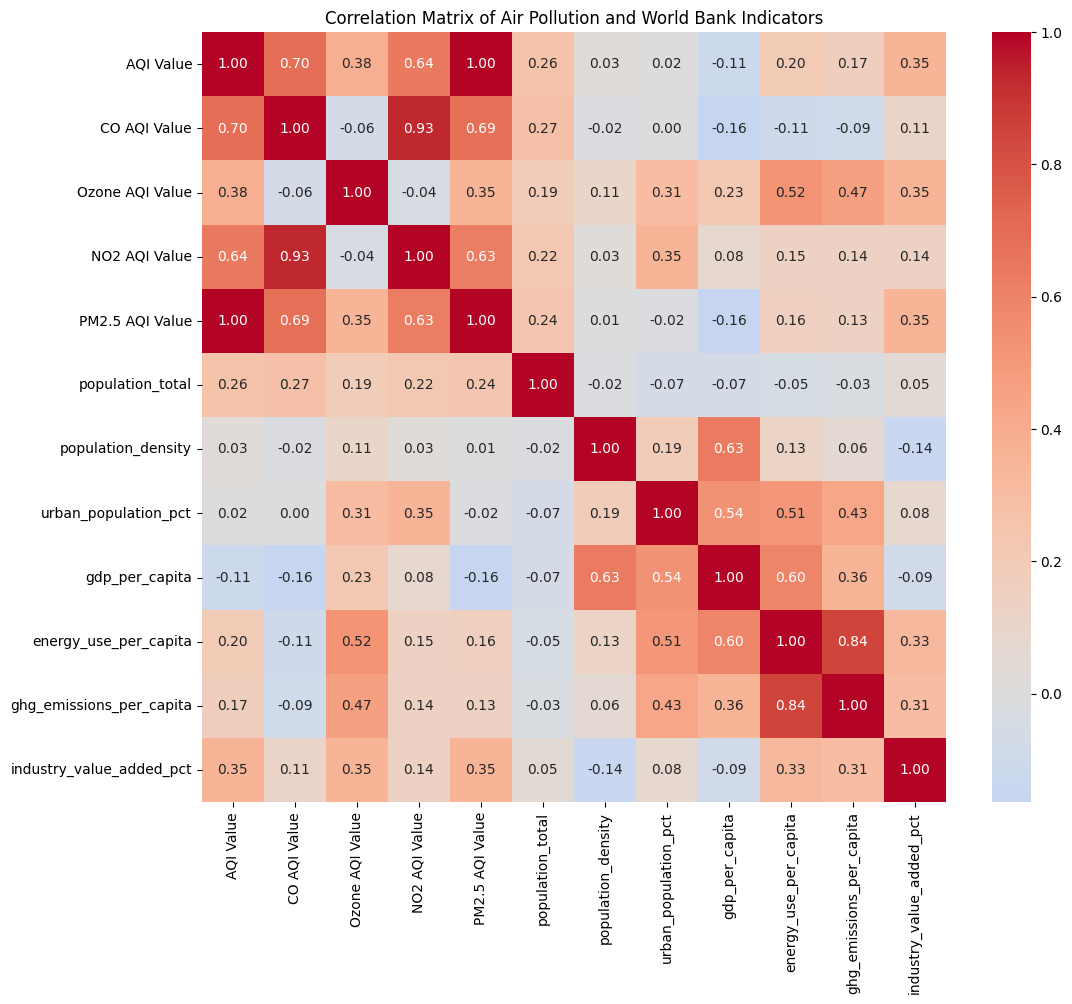

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = country_df.select_dtypes(include="number").corr()

plt.figure(figsize=(12,10))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Correlation Matrix of Air Pollution and World Bank Indicators")
plt.show()

In [ ]:
country_df.to_csv(
    "/content/country_level_air_pollution_world_bank_2023.csv",
    index=False
)

In [ ]:
country_df[["AQI Value","PM2.5 AQI Value"]].corr()

,AQI Value,PM2.5 AQI Value
AQI Value,1.000000,0.996231
PM2.5 AQI Value,0.996231,1.000000


In [ ]:
(country_df["AQI Value"] - country_df["PM2.5 AQI Value"]).describe()

,0
count,175.000000
mean,2.558024
std,3.948617
min,0.000000
25%,0.000000
50%,0.519651
75%,3.640525
max,16.904762


In [ ]:
corr_with_aqi = (
    country_df
    .corr(numeric_only=True)["AQI Value"]
    .sort_values(ascending=False)
)

corr_with_aqi

,AQI Value
AQI Value,1.000000
PM2.5 AQI Value,0.996231
CO AQI Value,0.695040
NO2 AQI Value,0.644948
Ozone AQI Value,0.383348
industry_value_added_pct,0.354363
population_total,0.261751
energy_use_per_capita,0.196875
ghg_emissions_per_capita,0.165559
population_density,0.028744


In [ ]:
corr_with_aqi.to_frame(
    "Correlation with AQI"
)

,Correlation with AQI
AQI Value,1.000000
PM2.5 AQI Value,0.996231
CO AQI Value,0.695040
NO2 AQI Value,0.644948
Ozone AQI Value,0.383348
industry_value_added_pct,0.354363
population_total,0.261751
energy_use_per_capita,0.196875
ghg_emissions_per_capita,0.165559
population_density,0.028744


In [ ]:
model_df = country_df[[
    "PM2.5 AQI Value",
    "population_total",
    "population_density",
    "urban_population_pct",
    "gdp_per_capita",
    "energy_use_per_capita",
    "ghg_emissions_per_capita",
    "industry_value_added_pct"
]].copy()

model_df = model_df.dropna()

print(model_df.shape)

(120, 8)


In [ ]:
country_df.to_csv(
    "country_level_air_pollution_world_bank_2023.csv",
    index=False
)

In [ ]:
from google.colab import files

files.download(
    "country_level_air_pollution_world_bank_2023.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
country_df.shape

(175, 13)

In [ ]:
country_df.isnull().sum()

,0
Country,0
AQI Value,0
CO AQI Value,0
Ozone AQI Value,0
NO2 AQI Value,0
PM2.5 AQI Value,0
population_total,20
population_density,20
urban_population_pct,20
gdp_per_capita,24


In [ ]:
skewness_table = (
    country_df
    .select_dtypes(include="number")
    .skew()
    .round(3)
    .to_frame(name="Skewness")
    .sort_values("Skewness", ascending=False)
)

skewness_table

,Skewness
NO2 AQI Value,11.500
CO AQI Value,10.057
population_density,9.879
population_total,7.505
ghg_emissions_per_capita,4.430
gdp_per_capita,3.803
AQI Value,3.294
PM2.5 AQI Value,3.047
energy_use_per_capita,2.866
Ozone AQI Value,2.799
